# Graph-DTW matching playground

**See which points/segments of edge A match which B edges — and play with the edge.**

- Every A sample point is painted in the color of the B-edge it matched, with a link to its
  matched B point: the correspondence reads directly off the picture. No analysis panels.
- Move the sliders (**shift / rotate / noise / translate / crop / ...**) and the match re-runs
  live against the unchanged B-network.
- In the last section you can **build your own sample** — edges are plain coordinate lists;
  add a B-edge by appending one line.

Kernel: `network-matching` (needs `ipywidgets`; `pip install ipywidgets` once if missing).

In [1]:
# Setup: the clean correspondence view (run once)
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.geometry import LineString

from network_matching import match_edge_to_bgraph
from network_matching.synthetic import (SCENARIOS, apply_perturbation, as_array,
                                        get_scenario, reverse)

PERTURB_ORDER = ["crop", "stretch", "rotate", "translate", "shift", "longitudinal", "noise"]


def to_edges(edge_list):
    """[(id, [(x, y), ...]), ...] -> [(id, LineString), ...] (already-LineString items pass through)."""
    return [(eid, g if isinstance(g, LineString) else LineString(g)) for eid, g in edge_list]


def draw_match(coords_a, b_edges, res, original_a=None, ax=None):
    """Show WHICH A point matched WHICH B edge/point -- nothing else."""
    M = res["metrics"]
    wp = res["warping_path"]                      # [((ax, ay), (bx, by)), ...]
    step_edge = M["warp_edge"]                    # matched B-edge id per pair
    route = [re["dest_id"] for re in M["route_edges"]]
    palette = [plt.cm.tab10(i) for i in (0, 1, 2, 4, 5, 6, 8, 9, 3, 7)]
    color = {eid: palette[i % len(palette)] for i, eid in enumerate(route)}

    if ax is None:
        _, ax = plt.subplots(figsize=(11, 7.5))

    # B network: matched edges in their own color, other candidates light gray
    for eid, geom in b_edges:
        xy = np.asarray(geom.coords if hasattr(geom, "coords") else geom, float)
        c = color.get(eid)
        if c is not None:
            ax.plot(xy[:, 0], xy[:, 1], color=c, lw=7, alpha=0.25, zorder=1,
                    solid_capstyle="round")
            ax.plot(xy[:, 0], xy[:, 1], color=c, lw=2.0, zorder=2)
        else:
            ax.plot(xy[:, 0], xy[:, 1], color="0.72", lw=1.6, zorder=2)
        ax.plot(xy[:, 0], xy[:, 1], "o", ms=3.5, lw=0,
                color=c if c is not None else "0.6", zorder=3)
        mid = xy[len(xy) // 2]
        ax.annotate(str(eid), mid, textcoords="offset points", xytext=(5, -12), fontsize=9,
                    color=c if c is not None else "0.45",
                    fontweight="bold" if c is not None else "normal")

    if original_a is not None:                    # the edge before perturbation, for reference
        O, A = np.asarray(original_a, float), np.asarray(coords_a, float)
        if O.shape != A.shape or not np.allclose(O, A):
            ax.plot(O[:, 0], O[:, 1], color="0.6", lw=1.4, ls="--", zorder=3)

    # the correspondence itself -- drawn the way the chosen emission actually matches:
    dbg = res.get("debug")
    seg_mode = bool(dbg) and dbg.get("params", {}).get("emission") == "segment" \
        and "arc_path" in dbg
    if seg_mode:
        # SEGMENT-TO-SEGMENT: one DP state = (A-segment, B-arc). Paint the A-segment in its
        # B-edge color and fill a ribbon between the two matched segments.
        gb = res["graph"]
        ap = dbg["a_pool"]
        arcs = dbg["arcs"]
        lo, hi = dbg.get("kept_span", (0, len(dbg["pairs_all"]) - 1))
        for t, (i, k, _mv) in enumerate(dbg["arc_path"]):
            if not (lo <= t + 1 <= hi):                 # state t produced alignment pair t+1
                continue                                # -> outside = trimmed overhang
            u, w_ = arcs[k]
            eid = gb.edge_ids[gb.vert_edge[u]]
            c = color.get(eid, "0.55")
            a0, a1 = ap[i][:2], ap[i + 1][:2]
            b0, b1 = (gb.vx[u], gb.vy[u]), (gb.vx[w_], gb.vy[w_])
            ax.fill(*zip(a0, a1, b1, b0), color=c, alpha=0.18, lw=0, zorder=4)
            ax.plot([a0[0], a1[0]], [a0[1], a1[1]], color=c, lw=4.5, alpha=0.9,
                    zorder=6, solid_capstyle="round")
            ax.plot([b0[0], b1[0]], [b0[1], b1[1]], color=c, lw=4.5, alpha=0.9,
                    zorder=5, solid_capstyle="round")
    else:
        # POINT-TO-POINT: one link per matched pair, A point painted in its B-edge color
        for k, (pa, pb) in enumerate(wp):
            c = color.get(step_edge[k], "0.55")
            ax.plot([pa[0], pb[0]], [pa[1], pb[1]], color=c, lw=1.2, alpha=0.8, zorder=4)
            ax.plot(pb[0], pb[1], "o", ms=5, color=c, zorder=5)
            ax.plot(pa[0], pa[1], "o", ms=7, color=c, mec="white", mew=1.0, zorder=7)

    A = np.asarray(coords_a, float)
    ax.plot(A[:, 0], A[:, 1], color="#111111", lw=2.2 if not seg_mode else 1.2, zorder=6)
    ax.plot(A[0, 0], A[0, 1], marker="^", ms=11, color="#111111", zorder=8)

    handles = [Line2D([], [], color="#111111", lw=2.2, marker="^", ms=8,
                      label="edge A (\u25b2 = start)")]
    handles += [Line2D([], [], color=color[eid], lw=3, label=f"matched \u2192 {eid}")
                for eid in route]
    if seg_mode:
        handles.append(Patch(facecolor="0.55", alpha=0.25,
                             label="A-segment \u2194 B-segment state"))
    if any(eid not in color for eid, _ in b_edges):
        handles.append(Line2D([], [], color="0.72", lw=2, label="candidate (unmatched)"))
    if original_a is not None:
        handles.append(Line2D([], [], color="0.6", lw=1.4, ls="--",
                              label="A before perturbation"))
    ax.legend(handles=handles, fontsize=8.5, loc="best", framealpha=0.95)

    view = "segment \u2194 segment" if seg_mode else "point \u2194 point"
    ttl = ("NO MATCH" if not np.isfinite(res["avg_distance"]) else
           " \u2192 ".join(str(e) for e in route)
           + f"   \u00b7   avg distance {res['avg_distance']:.2f} m"
           + f"   \u00b7   {view} view")
    ax.set_title(ttl, fontsize=11)
    ax.set_aspect("equal")
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    span = max(x1 - x0, y1 - y0)
    if (y1 - y0) < 0.35 * span:
        pad = (0.35 * span - (y1 - y0)) / 2
        ax.set_ylim(y0 - pad, y1 + pad)
    ax.grid(alpha=0.15)
    ax.tick_params(labelsize=8)
    return ax


def perturb_edge(coords_a, seed=0, reverse_dir=False, translate_bearing=90.0, **mags):
    """Apply the slider values (same order as the CLI scripts) and return the moved edge."""
    P = as_array(coords_a)
    for fam in PERTURB_ORDER:
        m = mags.get(fam, 0)
        if m:
            kw = {"bearing": translate_bearing} if fam == "translate" else {}
            P = apply_perturbation(P, fam, m, seed=seed, **kw)
    return reverse(P) if reverse_dir else P

print("ready \u2014", len(SCENARIOS), "built-in cases:", ", ".join(sorted(SCENARIOS)))

ready — 8 built-in cases: curve, cycle, gap, junction_turn, overhang, parallel_trap, split, stub


## Static example (no widgets)

One call = one picture. `parallel_trap` shifted 6 m toward the parallel road — every A point
shows which B-edge it ended up matched to.

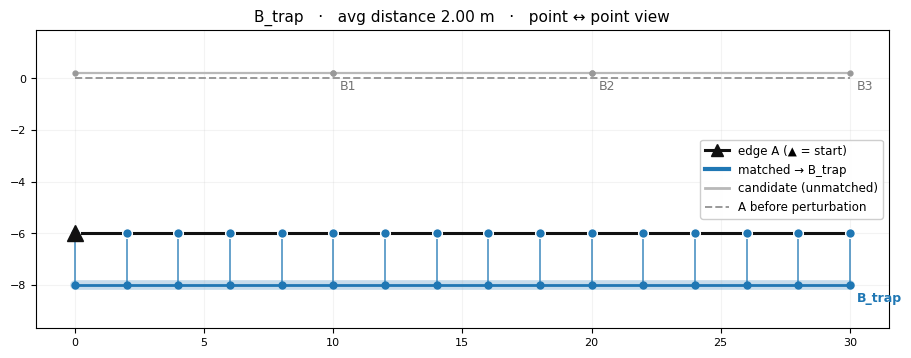

In [2]:
sc = get_scenario("parallel_trap")
A = perturb_edge(sc["coords_a"], shift=-6)

# every algorithm parameter, spelled out (the values shown are the LIBRARY defaults,
# except step_meters/snap, where the small synthetic cases use 2.0 / 0.5):
res = match_edge_to_bgraph(
    A.tolist(), sc["b_edges"],
    emission="point",        # local cost: "point" (point-to-point, default) or "segment"
    bearing_weight=0.0,      # lambda: heading penalty, SEGMENT MODE ONLY (0 = off, default)
    step_meters=2.0,         # gap-fill spacing: pools get extra points so no gap exceeds
                             #   this many meters (library default 10.0; falsy = no fill)
    snap_tolerance_m=0.5,    # B connectivity: end->start junction snap (library default 0.75)
    trim_ends_m=0.0,         # optional end-fragment cleanup (default 0 = off)
)
draw_match(A, sc["b_edges"], res, original_a=sc["coords_a"])
plt.show()

## Static example — segment-to-segment

With `emission="segment"` the DP matches **(A-segment, B-segment)** pairs, and the plot draws
them that way: each A-segment is painted in the color of the B-edge it matched, and a
translucent ribbon fills the area between the two matched segments (pass `debug=True` — the
segment states come from the debug payload). With `emission="point"` the plot shows
point-to-point links instead, which is what that cost model actually matches.

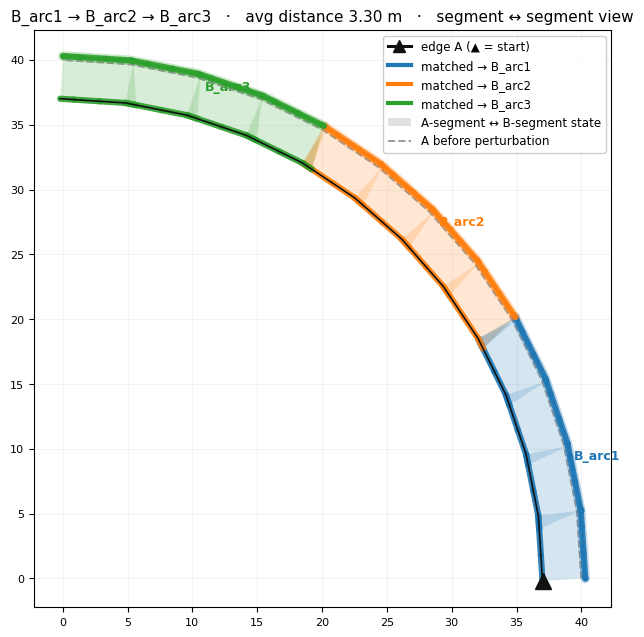

In [3]:
sc = get_scenario("curve")
A = perturb_edge(sc["coords_a"], shift=3)
res = match_edge_to_bgraph(A.tolist(), sc["b_edges"], emission="segment", debug=True,
                           **sc["defaults"])
draw_match(A, sc["b_edges"], res, original_a=sc["coords_a"])
plt.show()

## Interactive playground — built-in cases

Pick a case, drag the sliders, watch the correspondence change (sliders update on release).
The same sliders work on your own network in the last section.

### How the edge can be changed (slider → keyword → meaning)

Only **edge A moves** — the B-network never changes. In code, the same names are keywords of
`perturb_edge(...)` (and flags of the CLI scripts).

| Slider | Keyword | Unit | What it does |
|---|---|---|---|
| `shift m` | `shift` | m | Move **perpendicular to the road's own direction** (follows curves). + = left of travel, − = right. On a horizontal left→right edge that means: **+ = up, − = down.** |
| `along m` | `longitudinal` | m | Slide **lengthwise along the road** (a lengthwise misregistration). DTW can absorb much of it by re-warping. |
| `translate m` + `direction °` | `translate`, `translate_bearing` | m, ° | Rigid move in a **fixed compass direction**, independent of the edge's shape: **0 = up/north, 90 = right/east, 180 = down/south, 270 = left/west** (any angle works). Use this for guaranteed up/down on any edge. |
| `rotate °` | `rotate` | ° | Rotate the whole edge about its centroid (a bearing/registration error). |
| `noise σ` + `noise seed` | `noise`, `seed` | m | Gaussian jitter of every vertex. The edge is densified to 5 m spacing first, so even a 2-point edge gets a genuinely wiggly shape; `seed` picks the random pattern. |
| `crop %` | `crop` | % | Shorten: remove this % of total length, **half from each end** (a partial edge). |
| `stretch m` | `stretch` | m | Extend **both ends outward** along the end tangents (overhang past the B corridor). |
| `reverse direction` | `reverse_dir` | — | Flip the digitized direction. B is a **directed** table, so this should degrade to NO_MATCH unless a reverse twin edge exists. |

When several are set they compose in a fixed order — crop → stretch → rotate → translate →
shift → along → noise (→ reverse) — so slider settings and scripted `perturb_edge(...)` calls
give identical results.

In [4]:
import ipywidgets as w


def playground(coords_a=None, b_edges=None, snap=0.5, step=2.0):
    """Interactive matcher. No args -> built-in case chooser; or pass your own
    coords_a=[(x, y), ...] and b_edges=[(id, [(x, y), ...]), ...]."""
    custom = coords_a is not None
    if custom:
        b_edges = to_edges(b_edges)

    sl = dict(continuous_update=False, style={"description_width": "90px"},
              layout=w.Layout(width="340px"))
    k = {}
    if not custom:
        k["case"] = w.Dropdown(options=sorted(SCENARIOS), value="split", description="case",
                               style=sl["style"], layout=sl["layout"])
    k["emission"] = w.Dropdown(options=["point", "segment"], description="emission",
                               style=sl["style"], layout=sl["layout"])
    k["shift"] = w.FloatSlider(0, min=-16, max=16, step=0.5, description="shift m", **sl)
    k["longitudinal"] = w.FloatSlider(0, min=-16, max=16, step=0.5, description="along m", **sl)
    k["translate"] = w.FloatSlider(0, min=0, max=16, step=0.5, description="translate m", **sl)
    k["translate_bearing"] = w.FloatSlider(90, min=0, max=360, step=15,
                                           description="direction \u00b0", **sl)
    k["rotate"] = w.FloatSlider(0, min=-45, max=45, step=1, description="rotate \u00b0", **sl)
    k["noise"] = w.FloatSlider(0, min=0, max=5, step=0.25, description="noise \u03c3 m", **sl)
    k["seed"] = w.IntSlider(0, min=0, max=20, description="noise seed", **sl)
    k["crop"] = w.FloatSlider(0, min=0, max=80, step=5, description="crop %", **sl)
    k["stretch"] = w.FloatSlider(0, min=0, max=15, step=1, description="stretch m", **sl)
    k["reverse_dir"] = w.Checkbox(False, description="reverse direction")
    k["snap"] = w.FloatSlider(snap, min=0.1, max=3, step=0.1, description="snap tol m", **sl)
    k["step"] = w.FloatSlider(step, min=1, max=20, step=1, description="sample m", **sl)
    k["bearing_w"] = w.FloatSlider(0, min=0, max=1, step=0.05,
                                   description="bearing \u03bb", **sl)

    def update(**v):
        if custom:
            A0, B, kw = coords_a, b_edges, {}
        else:
            sc = get_scenario(v["case"])
            A0, B = sc["coords_a"], sc["b_edges"]
        A = perturb_edge(A0, seed=v["seed"], reverse_dir=v["reverse_dir"],
                         translate_bearing=v["translate_bearing"],
                         crop=v["crop"], stretch=v["stretch"], rotate=v["rotate"],
                         translate=v["translate"], shift=v["shift"],
                         longitudinal=v["longitudinal"], noise=v["noise"])
        res = match_edge_to_bgraph(A.tolist(), B, snap_tolerance_m=v["snap"],
                                   step_meters=v["step"], emission=v["emission"],
                                   bearing_weight=v["bearing_w"], debug=True)
        fig, ax = plt.subplots(figsize=(11, 7.5))
        draw_match(A, B, res, original_a=A0, ax=ax)
        plt.show()

    out = w.interactive_output(update, k)
    rows = [w.HBox([k[n] for n in names if n in k]) for names in
            (["case", "emission", "reverse_dir"], ["shift", "longitudinal", "rotate"],
             ["translate", "translate_bearing", "noise"], ["seed", "crop", "stretch"],
             ["snap", "step", "bearing_w"])]
    display(w.VBox(rows), out)


playground()

Output()

## Build your own sample — add edges

A network is just coordinate lists (meters, any local frame). **B is directed**: each edge is
walked in the order you type its points, and edges connect where one edge's *end* touches
another edge's *start* (within the snap tolerance). Add a B-edge by appending one
`("id", [(x, y), (x, y), ...])` line — then re-run the cell.

In [5]:
my_a = [(0, 1), (25, 1), (45, 12)]            # the edge to match (drawn black)

my_b_edges = [
    ("main_1",  [(0, 0), (12, 0)]),           # chain along A...
    ("main_2",  [(12, 0), (25, 0)]),
    ("ramp",    [(25, 0), (45, 11)]),         # ...bending off with A
    ("straight", [(25, 0), (45, 0)]),         # competing straight continuation
    ("side",    [(12, -9), (12, 0)]),         # side road digitized INTO the junction
    # ("new_edge", [(45, 11), (60, 18)]),     # <- add your next edge like this
]

playground(my_a, my_b_edges)

Output()

---
## Algorithm parameters (slider → keyword → default)

| Slider | Keyword | Default | Meaning |
|---|---|---|---|
| `emission` | `emission` | `"point"` | local cost model: `point` = point-to-point distance; `segment` = direction-aware endpoint-average of the traversed A-/B-segments |
| `bearing λ` | `bearing_weight` | `0.0` (off) | heading penalty λ · circular bearing difference (degrees), **segment mode only** — point mode ignores it. λ=0.1 means a 10° heading error costs like 1 m of drift |
| `sample m` | `step_meters` | `10.0` (cases here use `2.0`) | the "extra points": each edge's point pool = its own vertices + projections of the other side's vertices + gap-fill points so no gap exceeds this many meters. Smaller = denser = more points (and slower); set falsy in code to disable gap-fill |
| `snap tol` | `snap_tolerance_m` | `0.75` (cases here use `0.5`) | B-network connectivity: one edge's END joins another's START if they are within this distance — raise it to bridge the `gap` case, lower it to break chains apart |
| — | `trim_ends_m` | `0.0` (off) | optional cleanup that drops a leading/trailing route edge covering less than this many meters of A |

Try: case `split`, emission `segment`, rotate ~20° — then raise `bearing λ` from 0 to 0.5 and
watch the heading term start to matter. Or case `gap`: slide `snap tol` past 2.0 and the two
halves connect.

Deeper looks, when you want them: `scripts/graph_dtw_debug_viz.py` renders the DP internals for
any of these cases, `scripts/graph_dtw_perturb_test.py` sweeps whole perturbation families —
see `docs/graph_dtw_debugging.md`.

## Proof cell — point↔point vs segment↔segment, side by side

Same edge, same network, matched twice: left with `emission="point"` (thin links between
matched POINTS), right with `emission="segment"` (each matched **A-segment painted in its
B-edge color** + a translucent ribbon filling the matched segment pair — no point links).

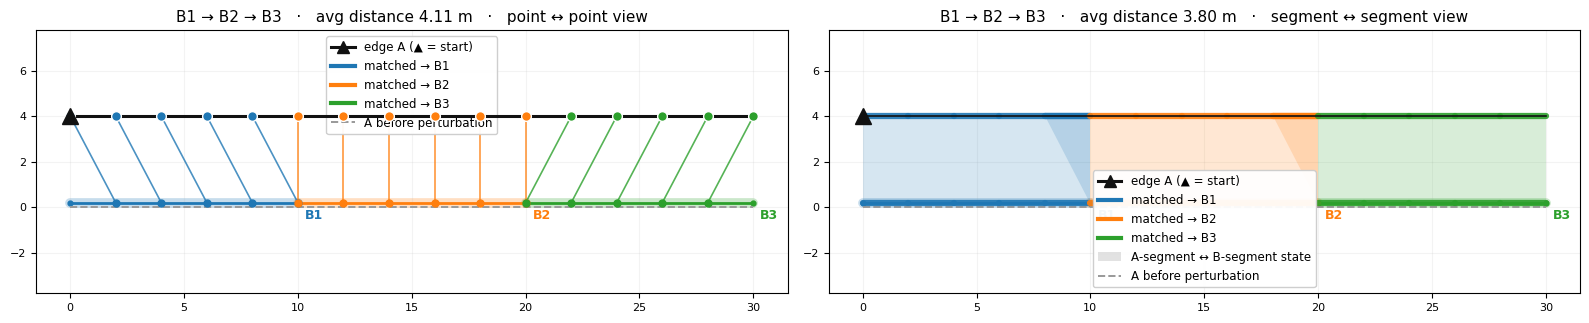

In [6]:
sc = get_scenario("split")
A = perturb_edge(sc["coords_a"], shift=4)          # shifted 4 m so the ribbons are visible

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ax, emission in zip(axes, ["point", "segment"]):
    res = match_edge_to_bgraph(A.tolist(), sc["b_edges"], emission=emission, debug=True,
                               **sc["defaults"])
    draw_match(A, sc["b_edges"], res, original_a=sc["coords_a"], ax=ax)
plt.tight_layout()
plt.show()